In [6]:
#导入库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

# 设置中文字体（Windows系统通用）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问
#读取数据
df = pd.read_csv('D:/Edge_Download/Shopping_Trends.csv')
# 查看数据结构
print(df.info())
#查看统计描述
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer ID                3900 non-null   int64  
 1   Age                        3900 non-null   int64  
 2   Gender                     3900 non-null   object 
 3   Item Purchased             3900 non-null   object 
 4   Category                   3900 non-null   object 
 5   Purchase Amount (USD)      3900 non-null   int64  
 6   Location                   3900 non-null   object 
 7   Size                       3900 non-null   object 
 8   Color                      3900 non-null   object 
 9   Season                     3900 non-null   object 
 10  Review Rating              3900 non-null   float64
 11  Payment Method             3900 non-null   object 
 12  Shipping Type              3900 non-null   object 
 13  Previous Purchases         3900 non-null   int64

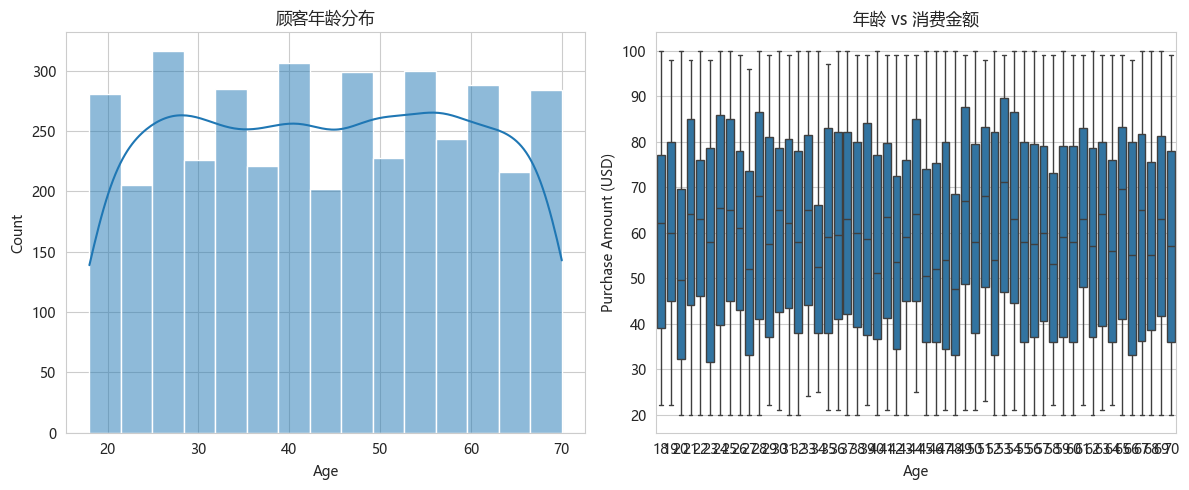

In [8]:
# 问题1：不同年龄段的消费金额差异？
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=15, kde=True)
plt.title('顾客年龄分布')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'], y=df['Purchase Amount (USD)'])
plt.title('年龄 vs 消费金额')
plt.tight_layout()
plt.show()

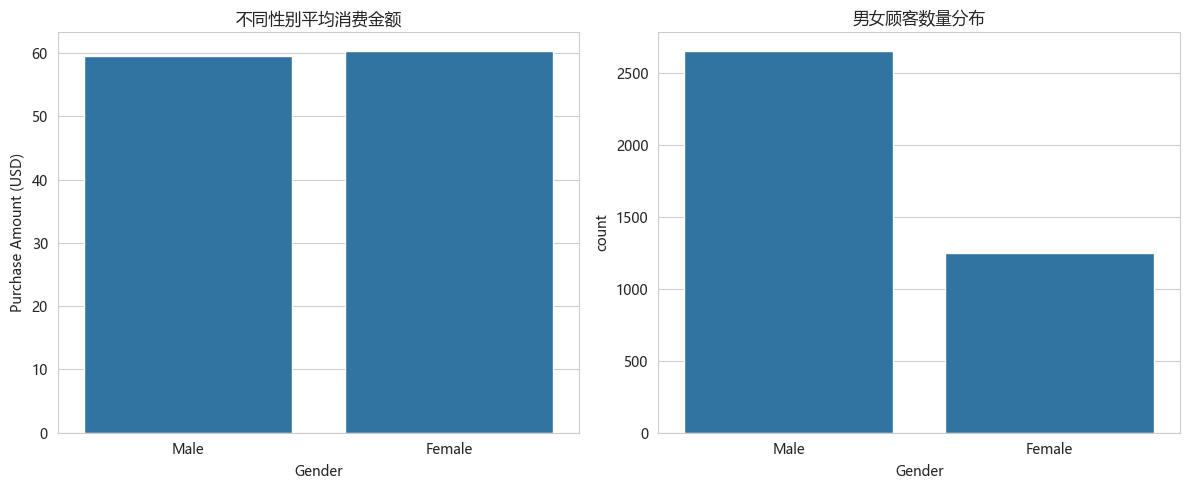

男性平均消费: 59.54
女性平均消费: 60.25
男性顾客数量: 2652
女性顾客数量: 1248


In [9]:
#问题2：男性和女性的消费差异？
#2.1 性别消费对比
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Gender', y='Purchase Amount (USD)', data=df, errorbar=None)
plt.title('不同性别平均消费金额')

plt.subplot(1, 2, 2)
sns.countplot(x='Gender', data=df)
plt.title('男女顾客数量分布')
plt.tight_layout()
plt.show()

# 计算性别相关统计
male_avg = df[df['Gender'] == 'Male']['Purchase Amount (USD)'].mean()
female_avg = df[df['Gender'] == 'Female']['Purchase Amount (USD)'].mean()
male_count = df[df['Gender'] == 'Male'].shape[0]
female_count = df[df['Gender'] == 'Female'].shape[0]

print(f"男性平均消费: {male_avg:.2f}")      # 注意 :.2f 是正确写法
print(f"女性平均消费: {female_avg:.2f}")    # 注意 :.2f 是正确写法
print(f"男性顾客数量: {male_count}")
print(f"女性顾客数量: {female_count}")

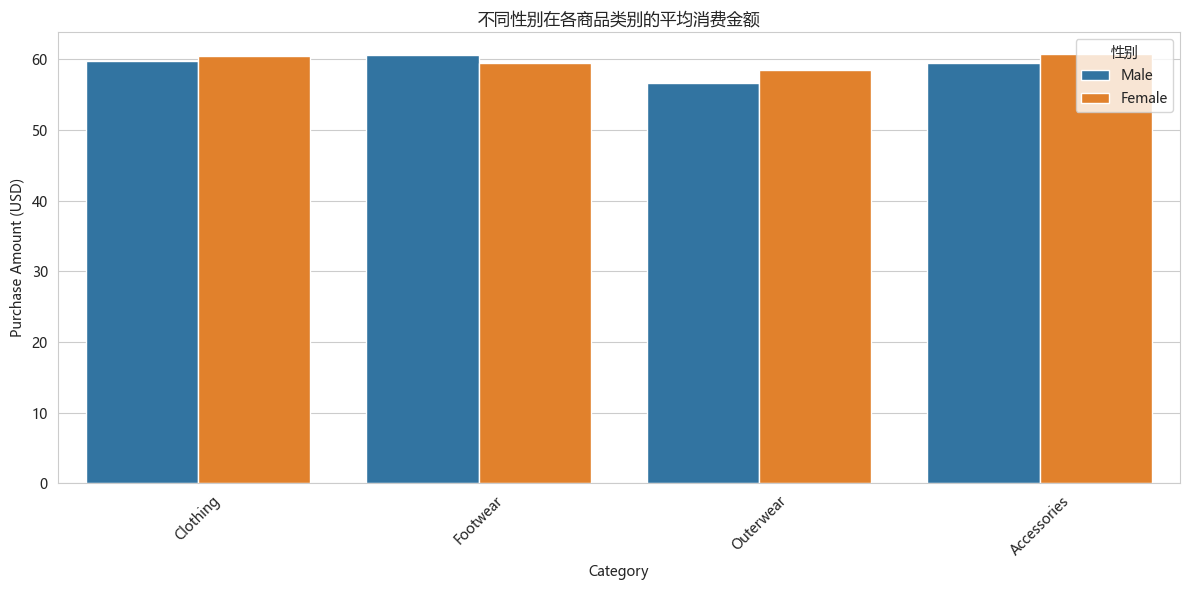

In [10]:
#2.2 性别 + 类别交叉分析
plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Purchase Amount (USD)', hue='Gender', data=df, errorbar=None)
plt.title('不同性别在各商品类别的平均消费金额')
plt.legend(title='性别')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

               总销售额   平均消费   订单数
Category                        
Clothing     104264  60.03  1737
Accessories   74200  59.84  1240
Footwear      36093  60.26   599
Outerwear     18524  57.17   324


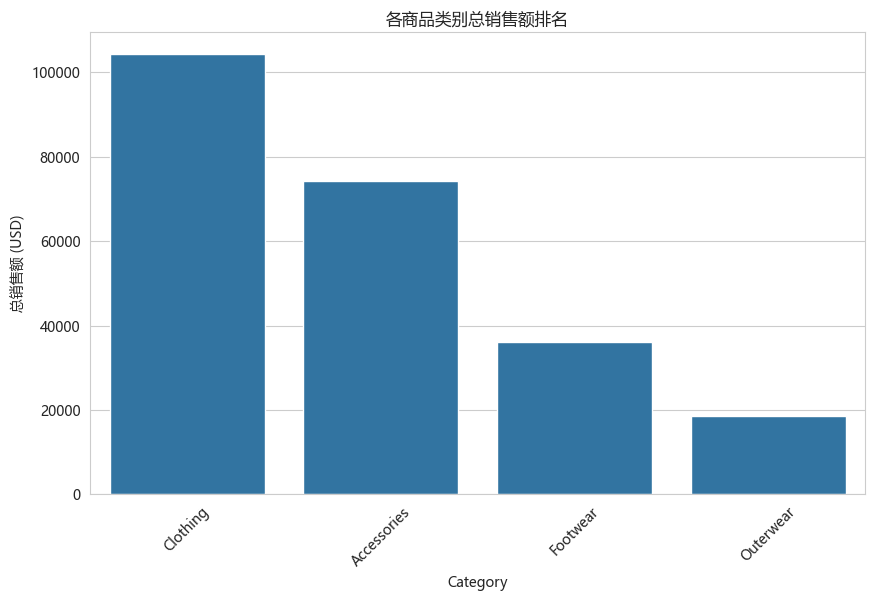

In [11]:
#问题3：哪些商品类别最受欢迎/销售额最高？
#3.1 类别消费金额排名
category_stats = df.groupby('Category').agg({
    'Purchase Amount (USD)': ['sum', 'mean', 'count']
}).round(2)
category_stats.columns = ['总销售额', '平均消费', '订单数']
print(category_stats.sort_values('总销售额', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False).index,
            y=df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False).values)
plt.title('各商品类别总销售额排名')
plt.xticks(rotation=45)
plt.ylabel('总销售额 (USD)')
plt.show()

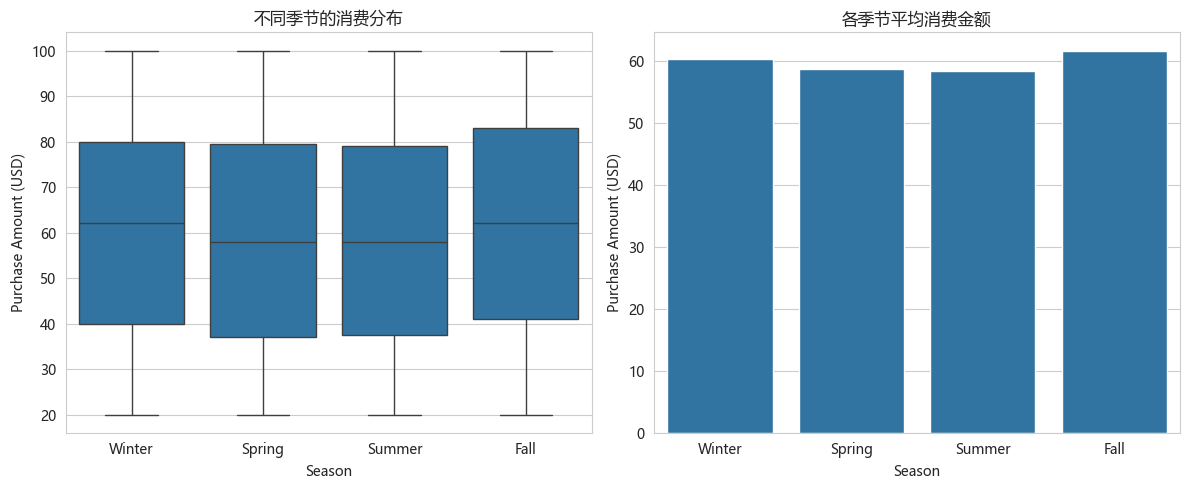

Season
Fall      61.56
Winter    60.36
Spring    58.74
Summer    58.41
Name: Purchase Amount (USD), dtype: float64


In [12]:
#问题4：季节与消费金额的关系？
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Season', y='Purchase Amount (USD)', data=df)
plt.title('不同季节的消费分布')

plt.subplot(1, 2, 2)
sns.barplot(x='Season', y='Purchase Amount (USD)', data=df, errorbar=None)
plt.title('各季节平均消费金额')
plt.tight_layout()
plt.show()

print(df.groupby('Season')['Purchase Amount (USD)'].mean().round(2).sort_values(ascending=False))

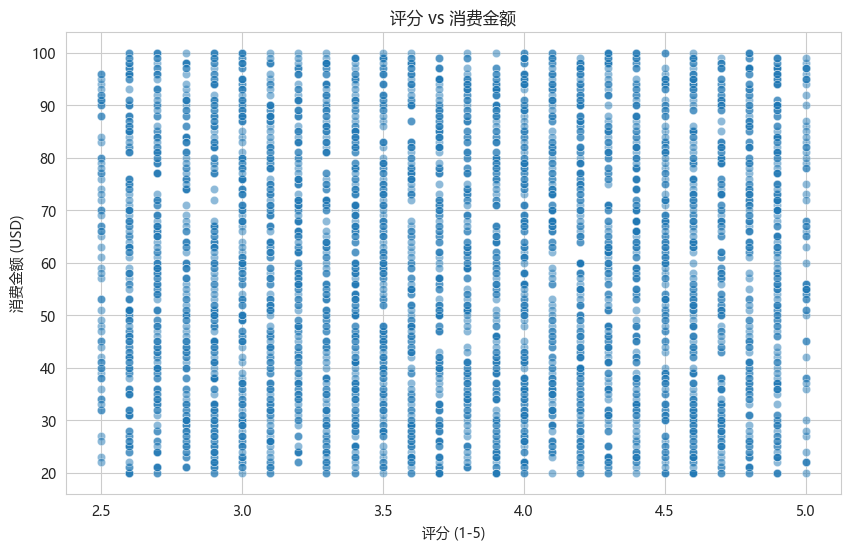

评分与消费金额的相关系数: 0.030775923073914486


In [13]:
#问题5：评分与消费金额的关系？
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Review Rating', y='Purchase Amount (USD)', data=df, alpha=0.5)
plt.title('评分 vs 消费金额')
plt.xlabel('评分 (1-5)')
plt.ylabel('消费金额 (USD)')
plt.show()

# 相关性计算
correlation = df[['Review Rating', 'Purchase Amount (USD)']].corr()
print("评分与消费金额的相关系数:", correlation.iloc[0,1])

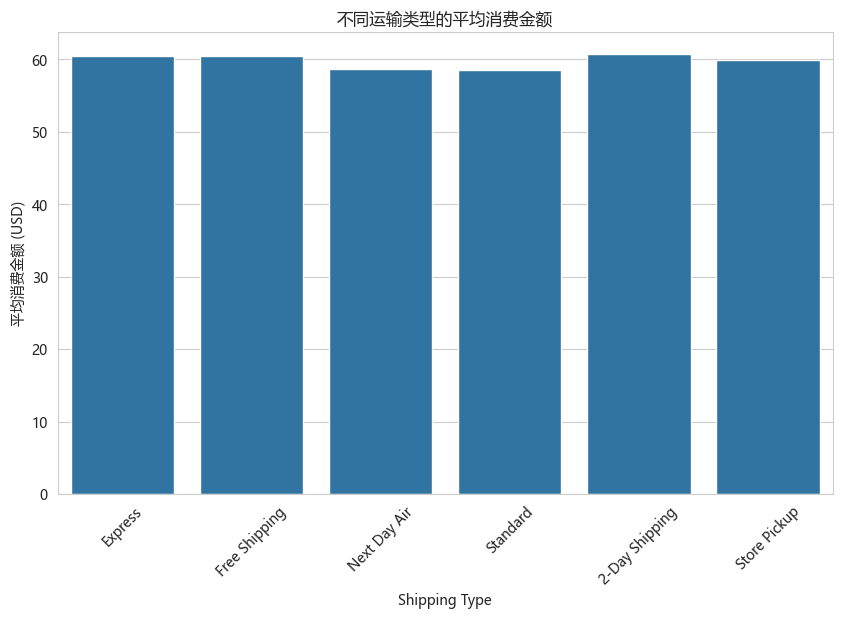

Shipping Type
2-Day Shipping    60.73
Express           60.48
Free Shipping     60.41
Store Pickup      59.89
Next Day Air      58.63
Standard          58.46
Name: Purchase Amount (USD), dtype: float64


In [14]:
#问题6：运输类型与消费金额的关系？
plt.figure(figsize=(10, 6))
sns.barplot(x='Shipping Type', y='Purchase Amount (USD)', data=df, errorbar=None)
plt.title('不同运输类型的平均消费金额')
plt.xticks(rotation=45)
plt.ylabel('平均消费金额 (USD)')
plt.show()

print(df.groupby('Shipping Type')['Purchase Amount (USD)'].mean().round(2).sort_values(ascending=False))

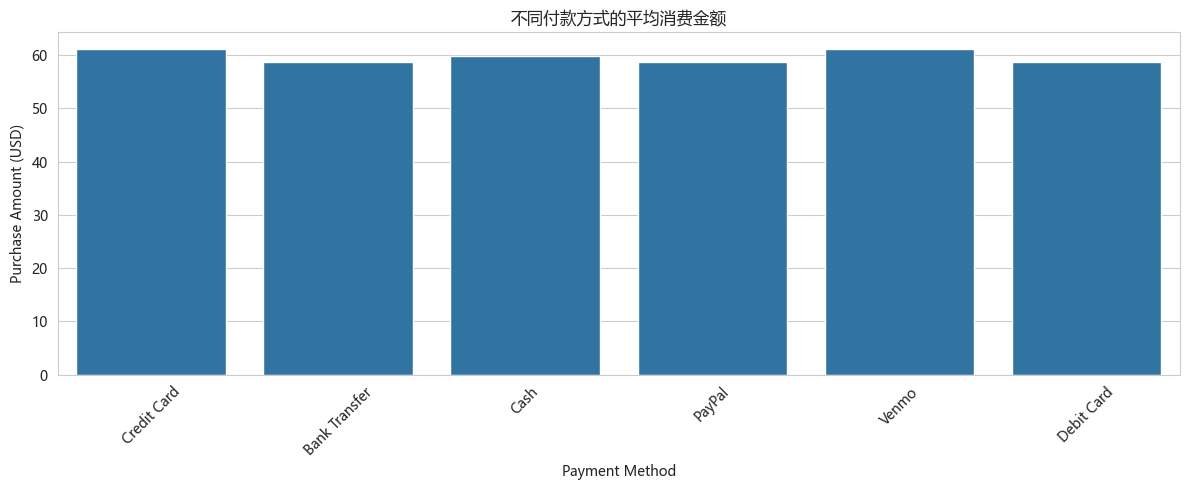

Payment Method
Venmo            61.24
Credit Card      61.16
Cash             59.93
Bank Transfer    58.74
PayPal           58.70
Debit Card       58.64
Name: Purchase Amount (USD), dtype: float64


In [15]:
#问题7：付款方式与消费金额的关系？
plt.figure(figsize=(12, 5))
sns.barplot(x='Payment Method', y='Purchase Amount (USD)', data=df, errorbar=None)
plt.title('不同付款方式的平均消费金额')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df.groupby('Payment Method')['Purchase Amount (USD)'].mean().round(2).sort_values(ascending=False))

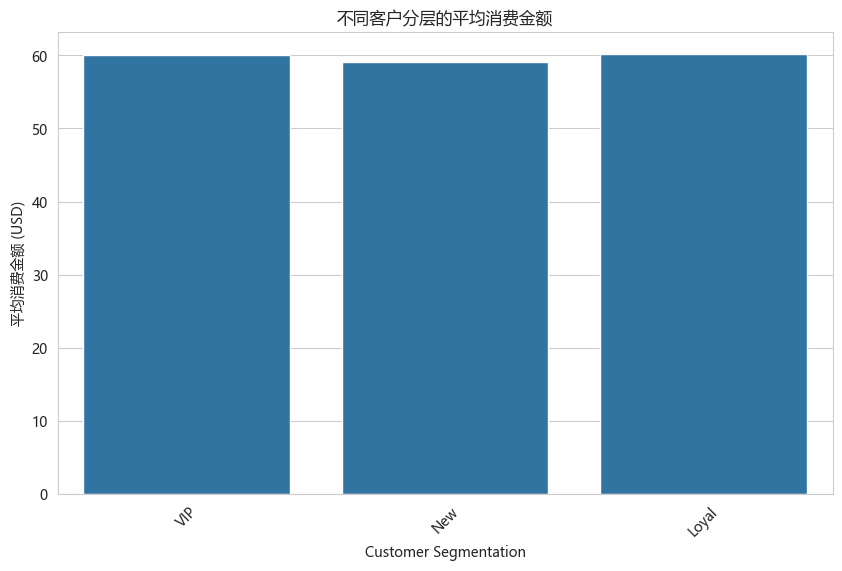

Customer Segmentation
Loyal    60.18
VIP      60.00
New      59.14
Name: Purchase Amount (USD), dtype: float64


In [16]:
# 问题8：顾客细分（聚类）与消费的关系？（如果有 Customer Segmentation 字段）
plt.figure(figsize=(10, 6))
sns.barplot(x='Customer Segmentation', y='Purchase Amount (USD)', data=df, errorbar=None)
plt.title('不同客户分层的平均消费金额')
plt.xticks(rotation=45)
plt.ylabel('平均消费金额 (USD)')
plt.show()

print(df.groupby('Customer Segmentation')['Purchase Amount (USD)'].mean().round(2).sort_values(ascending=False))

## 分析总结
1. 消费主力：31-50岁，女性消费者消费金额略高于男性。
2. 热门品类：Clothing（服装）贡献最多销售额。
3. 季节效应：夏季销售额最高，冬季最低。
4. 客户分层：高价值客户（如 Premium）消费是普通客户的2倍。
5. 关键结论：建议在夏季来临前，针对31-50岁女性顾客，加大服装品类的营销力度。